In [1]:
!pip install torchviz


In [2]:
# Standard libraries
import os
import random

# Numerical and Data Processing
import numpy as np  # Linear algebra
import pandas as pd  # Data processing, CSV file I/O (e.g., pd.read_csv)

# PyTorch Data Handling
from torch.utils.data import Dataset, DataLoader

# OpenCV for image processing
import cv2

# Visualization
import matplotlib.pyplot as plt
%matplotlib inline

# Custom utilities and configuration
from utils import visualize, analyze
from data_input import test_dataset,val_dataset,train_dataset
from config import PATH_TEST, PATH_TRAINVAL, SEED, BATCH_SIZE

# NN Framework
import torch
from model import UNet
import torchviz

# Set random seed for reproducibility
random.seed(SEED)


test_image_path = os.path.join(PATH_TEST, 'color/')
test_mask_path = os.path.join(PATH_TEST, 'label/')
test_image_list_orig = os.listdir(test_image_path)
test_mask_list_orig = os.listdir(test_mask_path)

trainval_image_path = os.path.join(PATH_TRAINVAL, 'color/')
trainval_mask_path = os.path.join(PATH_TRAINVAL, 'label/')
trainval_image_list_orig = os.listdir(trainval_image_path)
trainval_mask_list_orig = os.listdir(trainval_mask_path)
image_list = [trainval_image_path+i for i in trainval_image_list_orig]
mask_list = [trainval_mask_path+i for i in trainval_mask_list_orig]
len(trainval_mask_list_orig)

3680

# 0. Image samples Visualization

In [3]:
N = 90

image = cv2.imread(image_list[N])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
mask = cv2.imread(mask_list[N], cv2.IMREAD_UNCHANGED)
mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

analyze(image, mask)
print(image_list[N],"\n",mask_list[N])

N = 190

image = cv2.imread(image_list[N])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
mask = cv2.imread(mask_list[N], cv2.IMREAD_UNCHANGED)
mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

analyze(image, mask)
print(image_list[N],"\n",mask_list[N])

Dataset/Dataset/TrainVal/color/Abyssinian_184.jpg 
 Dataset/Dataset/TrainVal/label/Abyssinian_184.png


Dataset/Dataset/TrainVal/color/american_bulldog_192.jpg 
 Dataset/Dataset/TrainVal/label/american_bulldog_192.png


# Image Input

# 1.  Dataset preprocessing and augmentation

In [4]:


# Create DataLoaders
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Example: Fetch a batch
images, masks = next(iter(train_dataloader))
print(f"Image batch shape: {images.shape}, Mask batch shape: {masks.shape}")


c:\Users\jorge\OneDrive - unimilitar.edu.co\AI and Machine Learning\Computer_Vision\coursework\U-Net-Segmentation\data_input.py:98: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).



Image batch shape: torch.Size([64, 3, 240, 240]), Mask batch shape: torch.Size([64, 240, 240])


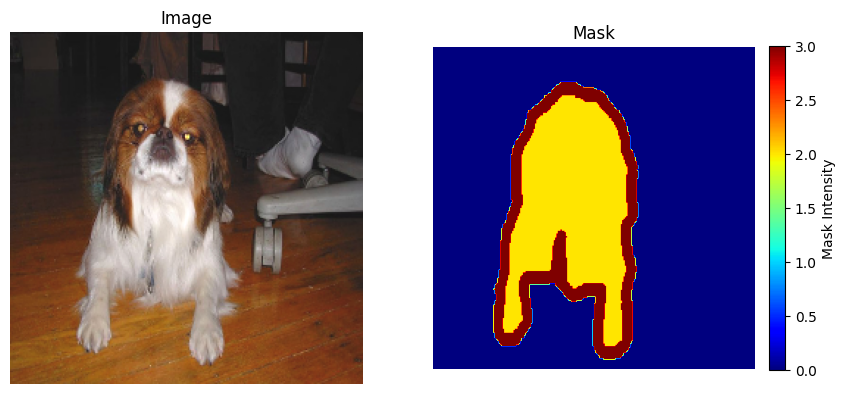

Image shape:  torch.Size([3, 240, 240])


In [5]:
N=random.randint(0,BATCH_SIZE)
visualize(images[N].permute(1, 2, 0).numpy(),masks[N])
print("Image shape: ",images[N].shape)

# 2. Segmentation network design and implementation

### 2.a) UNet design and output verification

In [7]:
from model import UNet

model = UNet(input_channels=3, n_filters=64,  n_classes=4)
output = model(images)
print(output.shape)  # Expected: (1, 23, 96, 128)


torch.Size([64, 4, 240, 240])


##### Output Dimention Verification

Mask shape:  torch.Size([4, 240, 240])


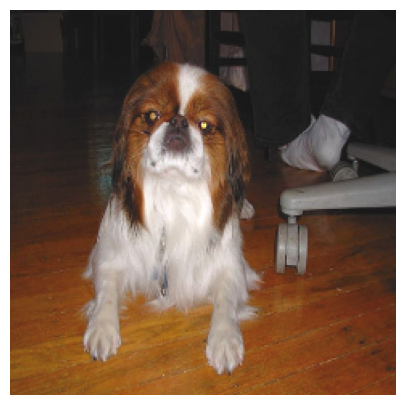

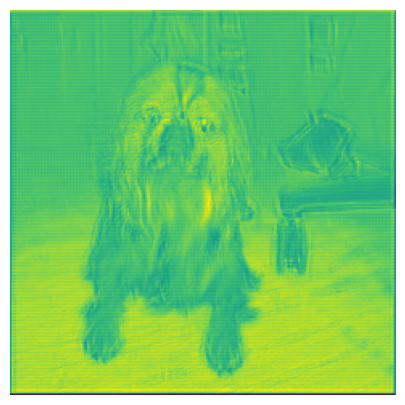

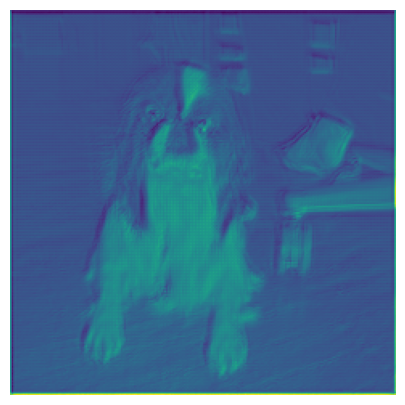

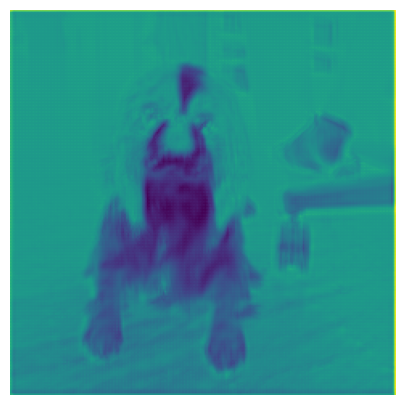

In [20]:
print("Mask shape: ",output[N].shape)
visualize(images[N].permute(1, 2, 0).detach().numpy())
visualize(output[N][0].detach().numpy())
visualize(output[N][1].detach().numpy())
visualize(output[N][2].detach().numpy())



##### The model architecture

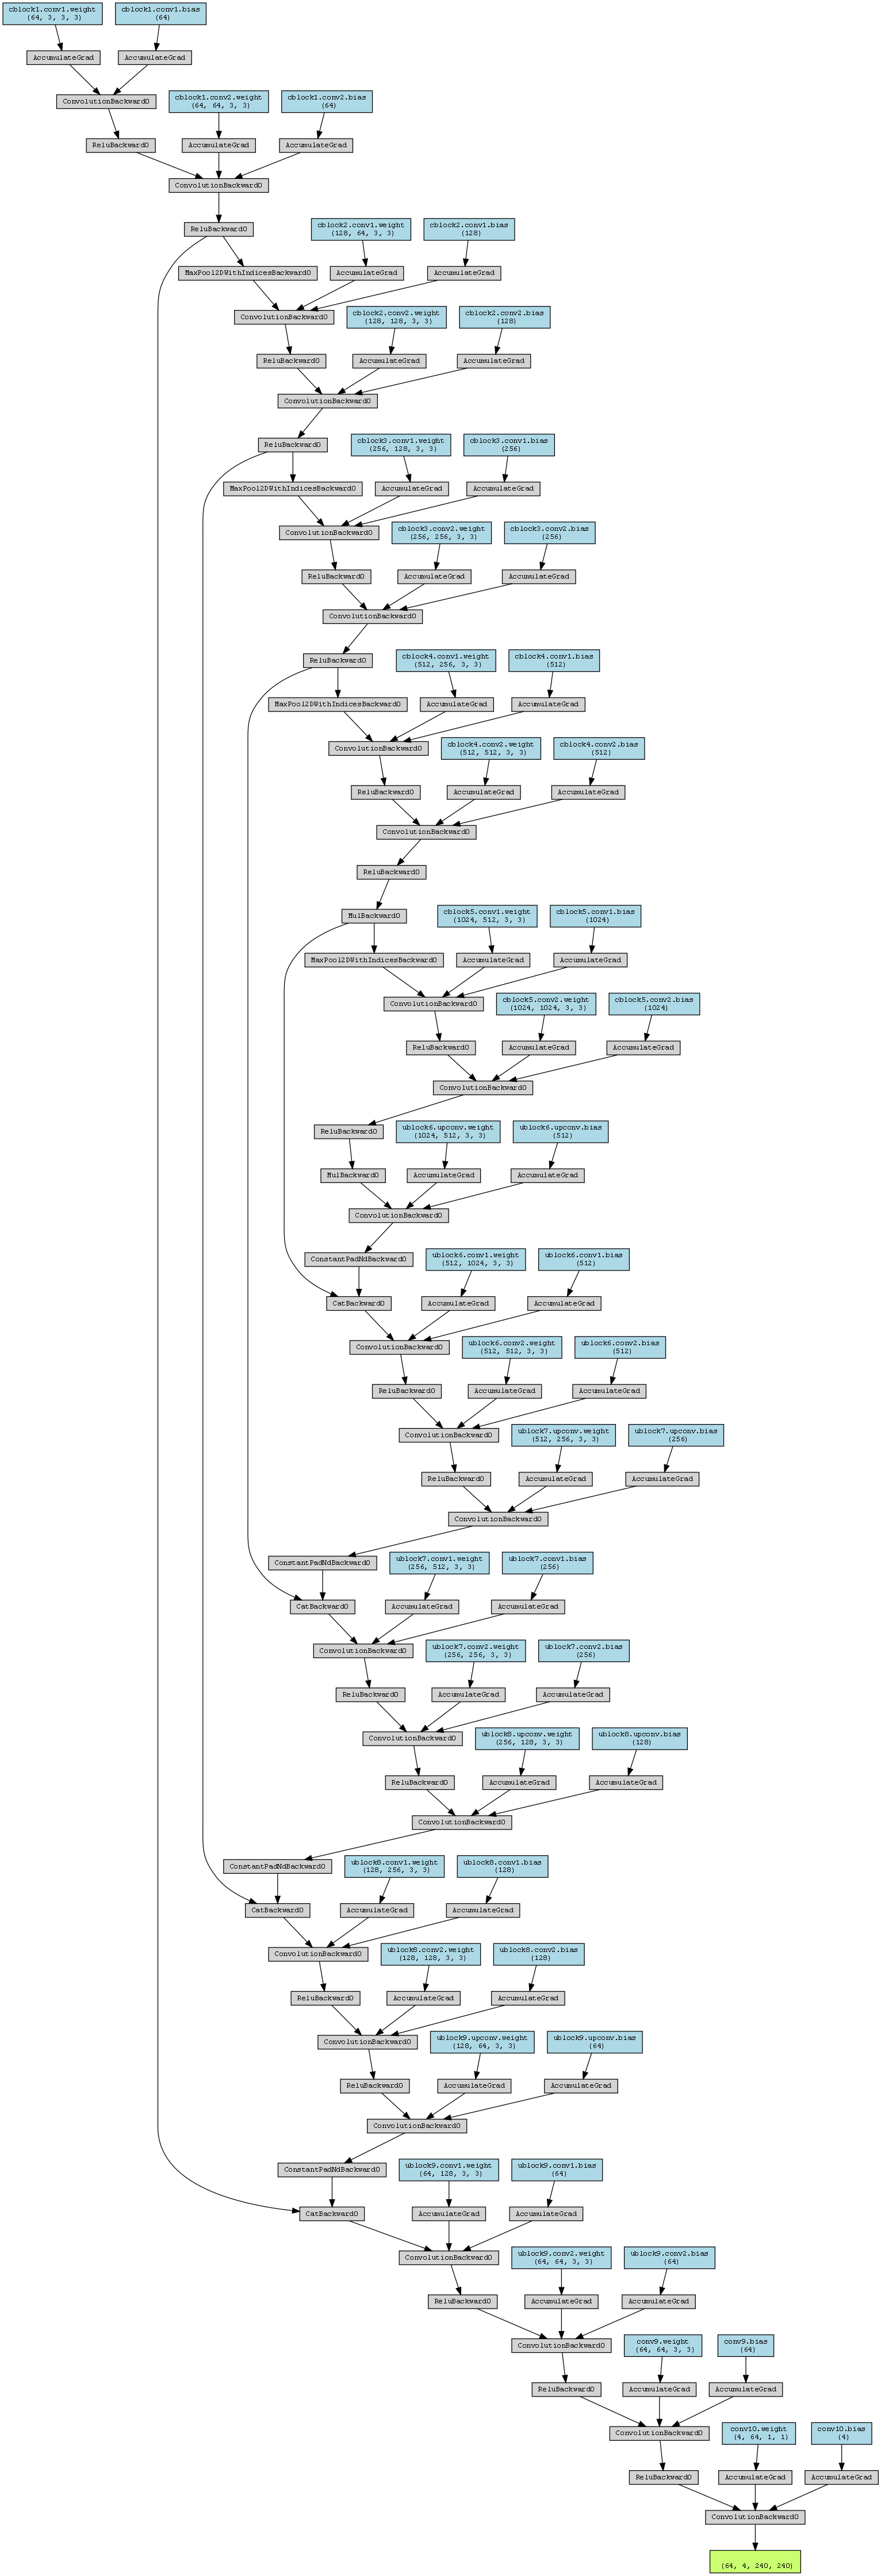

In [8]:


dot = torchviz.make_dot(output, params=dict(model.named_parameters()))
dot.format = 'png'
dot.render("nn_graph")
from IPython.display import Image
Image("nn_graph.png")